# Évaluation de la recherche sémantique française

Cette expérimentation utilise les jugements de pertinence du corpus FQuADRetrieval pour calculer Recall@k, MRR@k et le temps moyen de recherche.

In [1]:
from pathlib import Path
import sys
import time
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
DATASET_DIR = PROJECT_ROOT / 'data' / 'raw' / 'fquad_retrieval'
RESULTS_DIR = PROJECT_ROOT / 'evaluation' / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


In [2]:
corpus = pd.read_parquet(DATASET_DIR / 'corpus' / 'test-00000-of-00001.parquet')
queries = pd.read_parquet(DATASET_DIR / 'queries' / 'test-00000-of-00001.parquet')
qrels = pd.read_parquet(DATASET_DIR / 'qrels' / 'test-00000-of-00001.parquet')
relevant_by_query = qrels.groupby('query-id')['corpus-id'].agg(set).to_dict()
print(f'{len(corpus)} documents, {len(queries)} requêtes, {len(qrels)} jugements de pertinence')

269 documents, 400 requêtes, 400 jugements de pertinence


In [3]:
from src.embeddings import EmbeddingEncoder

MODEL_NAME = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
encoder = EmbeddingEncoder(MODEL_NAME)
document_texts = (corpus['title'].fillna('') + '. ' + corpus['text']).tolist()
document_embeddings = encoder.encode(document_texts, batch_size=32)
query_embeddings = encoder.encode(queries['text'].tolist(), batch_size=32)

/Users/joelkouraogo/Desktop/Master 2 IBAM ISIE Soutenance 2026/Projet/projet_vectoriel/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█| 199/19


In [4]:
def metrics_at_k(k: int) -> dict:
    recalls, reciprocal_ranks, latencies = [], [], []
    document_ids = corpus['_id'].to_numpy()
    for query_id, vector in zip(queries['_id'], query_embeddings):
        start = time.perf_counter()
        ranking = document_ids[(document_embeddings @ vector).argsort()[::-1][:k]]
        latencies.append((time.perf_counter() - start) * 1000)
        relevant = relevant_by_query.get(query_id, set())
        ranks = [rank for rank, doc_id in enumerate(ranking, start=1) if doc_id in relevant]
        recalls.append(float(bool(ranks)))
        reciprocal_ranks.append(1 / ranks[0] if ranks else 0)
    return {'k': k, 'Recall@k': sum(recalls) / len(recalls), 'MRR@k': sum(reciprocal_ranks) / len(reciprocal_ranks), 'Temps moyen (ms)': sum(latencies) / len(latencies)}

results = pd.DataFrame(metrics_at_k(k) for k in [1, 3, 5, 10])
results

,k,Recall@k,MRR@k,Temps moyen (ms)
0,1,0.400,0.400000,0.038821
1,3,0.595,0.486667,0.011043
2,5,0.680,0.505917,0.010823
3,10,0.775,0.518746,0.010716


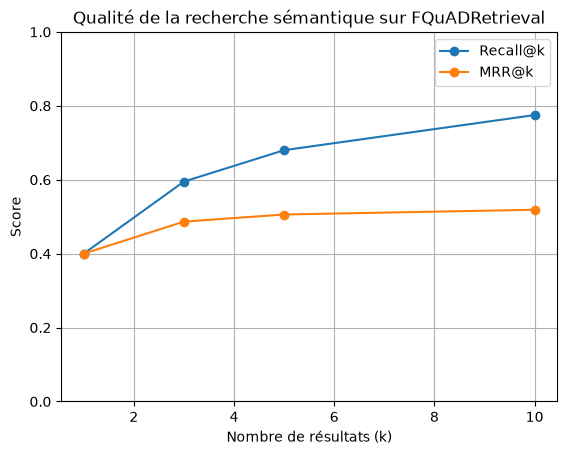

Résultats enregistrés dans : /Users/joelkouraogo/Desktop/Master 2 IBAM ISIE Soutenance 2026/Projet/projet_vectoriel/evaluation/results/fquad_metrics.csv


In [5]:
ax = results.plot(x='k', y=['Recall@k', 'MRR@k'], marker='o', ylim=(0, 1), grid=True, title='Qualité de la recherche sémantique sur FQuADRetrieval')
ax.set_xlabel('Nombre de résultats (k)')
ax.set_ylabel('Score')
plt.show()

output_file = RESULTS_DIR / 'fquad_metrics.csv'
results.to_csv(output_file, index=False)
print(f'Résultats enregistrés dans : {output_file}')

Les valeurs obtenues dans `fquad_metrics.csv` peuvent être reprises dans le chapitre d'expérimentation. Pour une comparaison scientifique, répétez le notebook avec plusieurs modèles ou tailles de passages.